In [3]:
import json 
import pandas as pd 

In [5]:
with open (r"E:\FCAI-HU\level4\semester2\nlu\Opinion-Mining-LLM\data\LLM responses for evaluation\qwen2.5-1.5B-instruct_responses.json", "r") as f:
    base_responses = json.load(f)
df_base = pd.DataFrame(base_responses)

with open (r"E:\FCAI-HU\level4\semester2\nlu\Opinion-Mining-LLM\data\LLM responses for evaluation\finetuned_LLM_responses.json", "r") as f:
    finetuned_responses = json.load(f)
df_finetuned = pd.DataFrame(finetuned_responses)


In [6]:
for i in range(5):
    print(f"Input: {df_base.iloc[i]['input']}\n")
    print(f"Base Model: {df_base.iloc[i]['prediction']}\n")
    print(f"Fine-tuned: {df_finetuned.iloc[i]['prediction']}\n")
    print("-" * 80)

Input: Boot time is super fast, around anywhere from 35 seconds to 1 minute.

Base Model: ```json
{
    "domain": "general",
    "aspects": [
        {
            "term": "boot time",
            "polarity": "positive"
        }
    ]
}
```

Fine-tuned: {"domain":"electronics","aspects":[{"term":"Boot time","polarity":"positive"}]}

--------------------------------------------------------------------------------
Input: tech support would not fix the problem unless I bought your plan for 150 plus.

Base Model: ```json
{
    "domain": "electronics",
    "aspects": [
        {
            "term": "tech support",
            "polarity": "negative"
        }
    ]
}
```

Fine-tuned: {"domain":"software","aspects":[{"term":"Tech support","polarity":"negative"}]}

--------------------------------------------------------------------------------
Input: but in resume this computer rocks!

Base Model: ```json
{
  "domain": "electronics",
  "aspects": [
    {
      "term": "computer",
      "pola

In [10]:
improvements=[]
for i in range(len(df_base)):
    base_pred = df_base.iloc[i]['prediction']
    fine_pred = df_finetuned.iloc[i]['prediction']
    
    if base_pred != fine_pred:
        improvements.append({
            'input': df_base.iloc[i]['input'],
            'base': base_pred,
            'finetuned': fine_pred
        })
print(f"Number of improved responses: {len(improvements)} out of {len(df_base)}")

for imp in improvements[:3]:
    print(f"\nInput: {imp['input']}")
    print(f"Before: {imp['base']}")
    print(f"After: {imp['finetuned']}")

Number of improved responses: 1572 out of 1572

Input: Boot time is super fast, around anywhere from 35 seconds to 1 minute.
Before: ```json
{
    "domain": "general",
    "aspects": [
        {
            "term": "boot time",
            "polarity": "positive"
        }
    ]
}
```
After: {"domain":"electronics","aspects":[{"term":"Boot time","polarity":"positive"}]}

Input: tech support would not fix the problem unless I bought your plan for 150 plus.
Before: ```json
{
    "domain": "electronics",
    "aspects": [
        {
            "term": "tech support",
            "polarity": "negative"
        }
    ]
}
```
After: {"domain":"software","aspects":[{"term":"Tech support","polarity":"negative"}]}

Input: but in resume this computer rocks!
Before: ```json
{
  "domain": "electronics",
  "aspects": [
    {
      "term": "computer",
      "polarity": "positive"
    }
  ]
}
```
After: {"domain":"electronics","aspects":[{"term":"computer","polarity":"positive"}]}


In [11]:
def is_valid_json(response_str):
    try:
        if '```' in response_str:
            response_str = response_str.split('```json')[-1].split('```')[0]
        json.loads(response_str.strip())
        return True
    except:
        return False

base_valid = df_base['prediction'].apply(is_valid_json).sum()
finetuned_valid = df_finetuned['prediction'].apply(is_valid_json).sum()

print(f"Base Model Valid JSON: {base_valid}/{len(df_base)} ({100*base_valid/len(df_base):.1f}%)")
print(f"Fine-tuned Valid JSON: {finetuned_valid}/{len(df_finetuned)} ({100*finetuned_valid/len(df_finetuned):.1f}%)")

Base Model Valid JSON: 1321/1572 (84.0%)
Fine-tuned Valid JSON: 1564/1572 (99.5%)


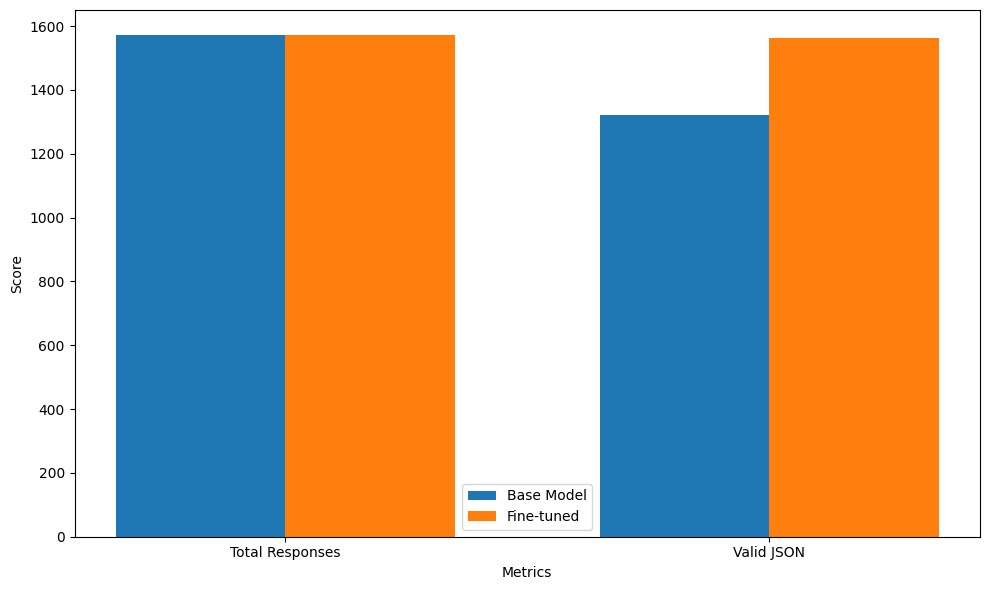

In [15]:
import matplotlib.pyplot as plt

metrics = ['Total Responses', 'Valid JSON']
base_scores = [len(df_base), base_valid]
finetuned_scores = [len(df_finetuned), finetuned_valid]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

ax.bar([i - width/2 for i in x], base_scores, width, label='Base Model')
ax.bar([i + width/2 for i in x], finetuned_scores, width, label='Fine-tuned')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [16]:
comparison_df = pd.DataFrame({
    'Input': df_base['input'],
    'Base Model Output': df_base['prediction'],
    'Fine-tuned Output': df_finetuned['prediction'],
    'Match': df_base['prediction'] == df_finetuned['prediction']
})

comparison_df.to_csv('model_comparison_results.csv', index=False)